# Kaggriculture: a market ledger that knows when it cannot know

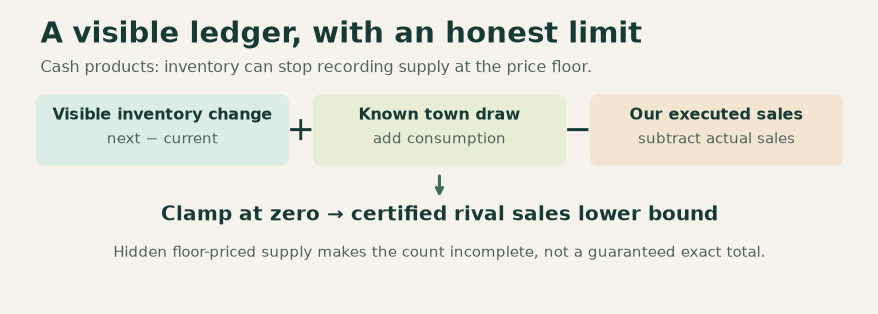

**Floor-aware visible-state attribution · 23 September 2026**

At a price of **1**, a sale still pays cash but may stop changing the visible market inventory. A useful opponent model should distinguish an exact count from a lower bound.

This notebook gives you a standalone Python ledger, editable examples, plots, and a failed-policy experiment worth learning from. Run all cells with CPU only and internet disabled. No Kaggle credentials, private opponent state, or historical replay files are required. The cover is a Matplotlib schematic of the accounting identity; the charts below are computed from their stated data.

## The accounting contract

The argument applies to **CARROT, TOMATO, STRAWBERRY, MELON, EGG, MILK, and WOOL** under the standard 1.32.7 rules. These cash products cannot be purchased through `BUY_PRODUCT`. Wheat and fertilizer require a ledger that also tracks purchases and are deliberately excluded.

Use consecutive observations and the town shops visible **before** the action. Define:

* `I`: current market inventory; `J`: next observed inventory; `C`: known town draw during this turn.
* `S`: our executed sale quantity, reconstructed from our **final** returned orders and own shed after field actions, respecting the ten-order limit.
* `A` and `B`: inventory increments caused by our sales and the opponent's sales. Each can be smaller than the actual number of units sold.

The inventory identity is `D = J - I + C = A + B`. Because `0 <= A <= S`, the opponent sold **at least** `max(0, D - S)` units. Floor censoring can hide supply; with an accurate `S`, it does not manufacture a positive lower bound.

**A sufficient exact-count criterion:** reconstruct the inventory before town consumption as `M = J + C`. If `price(M) > 1`, every sale was above the floor and the exact opponent quantity is `D - S`. Checking the next displayed quote alone is unsafe: town consumption can lift that quote after floor-priced trades occurred. A floor endpoint means this criterion is inconclusive, not that a floor-priced trade definitely occurred.

For a tighter bound, count `U = sum(price(I + j) > 1 for j in range(S))`. Rival supply can only lower our quotes, so `A <= U`, giving the certified lower bound `max(0, D - U)`. Once inventory is censored, there is generally no finite upper bound from these inventory observations alone.

## Reusable pure-Python ledger

The next cell is self-contained and can be copied into an agent. The seven price curves and town-demand constants describe standard 1.32.7 settings. Supply a matching custom price model and intervals if the configuration changes.

`record` needs your own post-field shed prediction. It is not enough to read the pre-action shed when this turn includes a `DROP`. Record only after every strategy layer has finished modifying its market orders. If only an upper bound on own sales is available, call `infer_rival_sales(..., own_quantity_exact=False)` so the result stays a bound.

In [1]:
"""Visible-state accounting for Kaggriculture 1.32.7 cash products.

Original educational implementation by prvsiyan's research workspace.
Behavior and numeric constants checked against Kaggle/kaggle-environments
(Apache-2.0). This is an accounting tool, not an agent or score claim.
"""
import math

CASH_PRODUCTS = ('CARROT', 'TOMATO', 'STRAWBERRY', 'MELON', 'EGG', 'MILK', 'WOOL')
SHOPS = {
    'BAKERY': ('EGG', 'WHEAT'),
    'PIZZA_SHOP': ('MILK', 'TOMATO', 'WHEAT'),
    'BRUNCH_SPOT': ('EGG', 'WHEAT', 'STRAWBERRY'),
    'YARN_STORE': ('WOOL',),
    'ICE_CREAM_SHOP': ('STRAWBERRY', 'MILK', 'WHEAT'),
    'PET_CAFE': ('CARROT',),
    'SMOOTHIE_SHOP': ('STRAWBERRY', 'MILK'),
    'FARMERS_MARKET': ('WHEAT', 'CARROT', 'TOMATO', 'STRAWBERRY'),
}
# base, scale, below shape, below strength, above shape, above strength
PRICE_RULES = {
    'CARROT': (35, 450, 'hinge', 1.00, 'sqrt', 0.70),
    'TOMATO': (60, 200, 'hinge', 0.40, 'sqrt', 0.60),
    'STRAWBERRY': (120, 100, 'sqrt', 0.70, 'linear', 1.60),
    'MELON': (250, 300, 'log', 0.20, 'sq', 3.60),
    'EGG': (50, 332, 'hinge', 0.40, 'log', 0.20),
    'MILK': (160, 122, 'sqrt', 0.60, 'linear', 1.60),
    'WOOL': (200, 105, 'log', 0.20, 'sq', 3.20),
}

def _shape(name, x, scale):
    if name == 'linear':
        return x
    if name == 'sq':
        return x * x
    if name == 'sqrt':
        return math.sqrt(x)
    if name == 'log':
        return math.log(1 + x)
    if name == 'hinge':
        u = x / scale
        return u + 8 * max(0, u - 1) ** 2
    raise ValueError('Unknown price curve')

def standard_cash_price(product, inventory):
    """Standard 1.32.7 settings only; pass another curve for custom parameters."""
    base, scale, lo, lo_strength, hi, hi_strength = PRICE_RULES[product]
    below = inventory < 10000
    shape, strength = (lo, lo_strength) if below else (hi, hi_strength)
    displacement = abs(inventory - 10000)
    change = strength * base * _shape(shape, displacement, scale) / _shape(shape, scale, scale)
    return max(1, int(round(base + change if below else base - change)))

def town_draw(step, shops, product, shop_interval=4, center_interval=24):
    """Use the shops visible BEFORE this turn; repeated instances each count."""
    if product not in CASH_PRODUCTS:
        raise ValueError('This cash-product ledger excludes WHEAT and FERTILIZER')
    if shop_interval < 1 or center_interval < 1:
        raise ValueError('Intervals must be positive')
    total = int(step % center_interval == 0)
    if step % shop_interval == 0:
        for name in shops:
            goods = SHOPS[name]
            if product in goods:
                total += 2 if len(goods) == 1 else 1
    return total

def final_cash_sell_quantity(post_field_shed, final_orders, product, order_cap=10):
    """Exact own quantity under standard rules, after all field actions.

    Cash products cannot be bought. Each accepted SELL removes units from our
    shed, even when its quote is one. Ignore anything after the order cap.
    The caller must supply the final returned order list and post-field shed.
    """
    if product not in CASH_PRODUCTS:
        raise ValueError('Cash-product-only calculation')
    requested = 0
    for order in final_orders[:order_cap]:
        if isinstance(order, list) and len(order) >= 3 and order[:2] == ['SELL', product]:
            try:
                requested += max(0, int(order[2]))
            except (ValueError, TypeError):
                pass
    return min(max(0, int(post_field_shed.get(product, 0))), requested)

def infer_rival_sales(before, after, draw, own_sales, price, own_quantity_exact=True):
    """Return a lower bound and, when certified, an exact rival sale count.

    Inputs are integer inventories, known town draw, and our executed quantity
    (or a conservative upper bound with own_quantity_exact=False). `price` must
    be the correct monotone, nonincreasing quote curve for this product.
    """
    values = (before, after, draw, own_sales)
    if any(isinstance(x, bool) or int(x) != x for x in values):
        raise ValueError('Use integer observations and quantities')
    before, after, draw, own_sales = map(int, values)
    if min(draw, own_sales) < 0:
        raise ValueError('Draw and own quantity must be nonnegative')
    total_supply = after - before + draw
    if total_supply < 0:
        raise ValueError('Inventory identity failed: check product, timing, and town draw')
    pre_town_end = after + draw
    own_supply_upper = sum(price(before + j) > 1 for j in range(own_sales))
    simple_lower = max(0, total_supply - own_sales)
    tighter_lower = max(0, total_supply - own_supply_upper)
    exact = None
    if own_quantity_exact and price(pre_town_end) > 1:
        exact = total_supply - own_sales
        if exact < 0:
            raise ValueError('Own quantity is inconsistent with an above-floor turn')
    return {
        'visible_supply': total_supply,
        'pre_town_inventory': pre_town_end,
        'pre_town_price': price(pre_town_end),
        'simple_lower_bound': simple_lower,
        'own_supply_upper_bound': own_supply_upper,
        'rival_lower_bound': tighter_lower,
        'rival_exact': exact,
        'status': 'exact' if exact is not None else 'lower bound only',
    }

class VisibleMarketLedger:
    """Record our final action now; consume the next visible observation later.

    The caller supplies its own post-field shed prediction. No opponent
    inventory, future town shop, game seed, or opponent identity is read.
    """
    def __init__(self, price_model=standard_cash_price, shop_interval=4, center_interval=24):
        self.price_model = price_model
        self.shop_interval = shop_interval
        self.center_interval = center_interval
        self.pending = None

    @staticmethod
    def _step(observation):
        return int(observation.get('step', 24 * observation.get('day', 0) + observation.get('hour', 0)))

    def record(self, observation, final_action, post_field_shed):
        step = self._step(observation)
        self.pending = {
            'step': step,
            'inventory': dict(observation['market']['inventory']),
            'shops': list(observation.get('town', {}).get('unlocked_shops', [])),
            'own': {p: final_cash_sell_quantity(post_field_shed, final_action.get('market', []), p)
                    for p in CASH_PRODUCTS},
        }

    def consume(self, next_observation):
        if self.pending is None:
            raise ValueError('Record a final action first')
        old = self.pending
        if self._step(next_observation) != old['step'] + 1:
            raise ValueError('Expected exactly the next observation')
        result = {}
        for p in CASH_PRODUCTS:
            draw = town_draw(old['step'], old['shops'], p, self.shop_interval, self.center_interval)
            result[p] = infer_rival_sales(old['inventory'][p], next_observation['market']['inventory'][p],
                                         draw, old['own'][p], lambda inv, item=p: self.price_model(item, inv))
        self.pending = None
        return result

## An editable miniature market

To make the mechanism easy to see, the examples use the toy quote `max(1, 10 - inventory)`. This is **not** a Kaggriculture price curve. The sale mechanics match the relevant rule: both players receive the quote computed before their same-slot unit trades; inventory increases only for quotes greater than one. The simulator knows the synthetic truth so we can check the ledger. The ledger itself sees only before/after inventory, known draw, and own sale quantity.

In [2]:
from pprint import pprint
from pathlib import Path
import csv
import json
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

OUT = Path('floor_ledger_outputs')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 13})
toy_price = lambda inventory: max(1, 10 - inventory)

def simulate_visible_turn(initial, own, rival, draw, price=toy_price):
    inventory = initial
    cash = [0, 0]
    supply = [0, 0]
    for unit in range(max(own, rival)):
        quote = price(inventory)  # Quote both before committing either.
        for player, quantity in enumerate((own, rival)):
            if unit < quantity:
                cash[player] += quote
                if quote > 1:
                    inventory += 1
                    supply[player] += 1
    return {'before': initial, 'after': inventory-draw, 'draw': draw,
            'own': own, 'rival_truth': rival, 'own_cash': cash[0], 'rival_cash': cash[1],
            'own_inventory_increment': supply[0], 'rival_inventory_increment': supply[1]}

# Edit these four parameters in each row, then rerun from this cell.
EXAMPLES = [
    ('Above floor', 0, 2, 3, 1),
    ('Floor, then town recovery', 5, 8, 7, 3),
    ('Tighter lower bound', 8, 8, 4, 0),
]
examples=[]
for label, initial, own, rival, draw in EXAMPLES:
    row=simulate_visible_turn(initial, own, rival, draw)
    result=infer_rival_sales(row['before'],row['after'],row['draw'],row['own'],toy_price)
    examples.append({'example':label, **row, **result})

columns=['example','rival_truth','visible_supply','rival_lower_bound','rival_exact','pre_town_price','status']
table='| '+' | '.join(columns)+' |\n| '+' | '.join(['---']*len(columns))+' |\n'
table+='\n'.join('| '+' | '.join(str(row[c]) for c in columns)+' |' for row in examples)
display(Markdown(table))
with (OUT/'editable_examples.csv').open('w', newline='') as f:
    writer=csv.DictWriter(f,fieldnames=list(examples[0]));writer.writeheader();writer.writerows(examples)

In the recovery example, seven rival units were sold but the public inventory reports only four supply increments from both players combined. After the town takes three units, the displayed toy quote rises to four. The reconstructed pre-town quote remains one, correctly preventing an exact-count claim.

In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,4.1),layout='constrained')
xs=list(range(0,15))
axes[0].step(xs,[toy_price(x) for x in xs],where='post',color='#23566b',linewidth=2)
axes[0].axhline(1,color='#b6444c',linestyle='--',label='price floor')
axes[0].scatter([6,9],[toy_price(6),toy_price(9)],c=['#527f59','#b6444c'],s=70,zorder=5)
axes[0].annotate('next observation after town draw',(6,4),xytext=(1,6),arrowprops={'arrowstyle':'->'})
axes[0].annotate('reconstructed pre-town end',(9,1),xytext=(5,2.8),arrowprops={'arrowstyle':'->'})
axes[0].set(xlabel='Toy public inventory',ylabel='Unit quote',title='Town recovery can hide a floor event')
axes[0].legend(frameon=False)

sweep=[]
for rival in range(25):
    row=simulate_visible_turn(5,8,rival,3)
    out=infer_rival_sales(row['before'],row['after'],3,8,toy_price)
    sweep.append({'rival_units':rival,**out})
axes[1].plot([x['rival_units'] for x in sweep],[x['visible_supply'] for x in sweep],label='visible supply from both players',color='#23566b')
axes[1].plot([x['rival_units'] for x in sweep],[x['rival_lower_bound'] for x in sweep],label='certified rival lower bound',color='#b6444c')
axes[1].plot([0,24],[0,24],linestyle=':',color='#527f59',label='synthetic rival truth')
axes[1].set(xlabel='Synthetic rival units sold',ylabel='Units',title='Many hidden quantities share one observation')
axes[1].legend(frameon=False)
fig.savefig(OUT/'floor_and_ambiguity.png',bbox_inches='tight')
plt.show()

## A small exhaustive check, plus a stale-snapshot trap

The following checks 3,146 editable synthetic cases. It verifies the lower bounds never exceed the simulated rival quantity and every certified exact result equals that quantity. This tests the mathematical examples; it is not a tournament or an official-score evaluation.

The last assertion demonstrates a different bug: if we really sell four units but tell the ledger that we sold zero, it can attribute all four to the opponent. Price-floor handling cannot repair an incorrect own-action snapshot.

In [4]:
checked=0
exact_cases=0
for initial in range(13):
    for own in range(11):
        for rival in range(11):
            for draw in (0,3):
                row=simulate_visible_turn(initial,own,rival,draw)
                estimate=infer_rival_sales(initial,row['after'],draw,own,toy_price)
                assert 0 <= estimate['simple_lower_bound'] <= estimate['rival_lower_bound'] <= rival
                if estimate['rival_exact'] is not None:
                    assert estimate['rival_exact']==rival
                    exact_cases+=1
                checked+=1
assert checked==3146
trap=simulate_visible_turn(0,4,0,0)
correct=infer_rival_sales(0,trap['after'],0,4,toy_price)
stale=infer_rival_sales(0,trap['after'],0,0,toy_price)
assert correct['rival_exact']==0 and stale['rival_exact']==4
print(f'{checked:,} synthetic cases passed; {exact_cases:,} certified exact cases.')
print('Same observation with correct vs stale own snapshot:',correct['rival_exact'],stale['rival_exact'])

## Connecting it to consecutive visible observations

This integration example uses the actual standard milk curve. Our final order sells six milk units; the next market inventory has risen by nine with no town draw, so the rival count is exactly three. `post_field_shed` belongs to us and is supplied by our field-action model. The ledger never requests the opponent's shed.

The repeated-shop assertion matters: two yarn stores consume four wool units on a shop tick, and the town center adds one on its own tick. Shops that unlock at the end of this turn are not yet consumers for this transition.

In [5]:
old_observation={'step':1,'market':{'inventory':{p:10000 for p in CASH_PRODUCTS}},
                 'town':{'unlocked_shops':[]}}
next_observation={'step':2,'market':{'inventory':{p:10000 for p in CASH_PRODUCTS}},
                  'town':{'unlocked_shops':[]}}
next_observation['market']['inventory']['MILK']=10009
final_action={'farmer':['DROP'],'hands':[],'market':[['SELL','MILK',6]]}
post_field_shed={'MILK':6}
ledger=VisibleMarketLedger()
ledger.record(old_observation,final_action,post_field_shed)
milk_result=ledger.consume(next_observation)['MILK']
assert milk_result['rival_exact']==3
assert town_draw(24,['YARN_STORE','YARN_STORE'],'WOOL')==5
assert final_cash_sell_quantity({'MILK':8},[['INVALID']]*10+[['SELL','MILK',8]],'MILK')==0
pprint(milk_result)

## Better accounting did not make our tested policy better

There are two separate results in our completed local research:

1. **Accounting verification:** two terminal 719-action traces gave 10,066 cash-product/turn checks. All inventory identities passed; 9,401 satisfied the sufficient exact-count criterion. In 74 checks, our executed sale count exceeded our inventory contribution. The tighter bound improved 58 checks. These categories overlap. This notebook reports that verified receipt; it does not pretend to rerun those private local traces.
2. **Policy experiment:** a fresh 560-game panel tested seven arms over eight seeds, five opponents, and both seats (80 games per arm). Synchronizing the final own-sale snapshot corrected attribution telemetry but made the tested forecasting controller worse. The own-only and own-plus-leftover variants had identical outcomes: 56 wins, zero ties, 24 losses, versus their control's 64/0/16. Mean terminal cash margin fell by **236.075**. Neither repair passed the frozen selection gates, and neither was promoted from this experiment.

Why can this happen? A forecast policy is a chain: ledger → historical match → predicted sale timing → final market orders. Changing a correct input changes which historical match is chosen. Correctness of the ledger is not a theorem about the downstream forecasting objective. The observed regression supports rejecting these particular integrations, not retaining incorrect accounting as a general principle. Eight seed blocks, not 80 independent seeds, are the sampling units here. All these results are local evidence; none is an official Kaggle score.

In [6]:
local_panel=[
    {'variant':'Control','wins':64,'ties':0,'losses':16,'mean_cash_margin':543.750},
    {'variant':'Final own-sale snapshot','wins':56,'ties':0,'losses':24,'mean_cash_margin':307.675},
    {'variant':'Own sale + leftover snapshot','wins':56,'ties':0,'losses':24,'mean_cash_margin':307.675},
]
fig,axes=plt.subplots(1,2,figsize=(12,4.1),layout='constrained')
names=[r['variant'] for r in local_panel]
ys=list(range(len(names)))
axes[0].barh(ys,[r['wins'] for r in local_panel],color='#527f59',label='wins')
axes[0].barh(ys,[r['losses'] for r in local_panel],left=[r['wins'] for r in local_panel],color='#b6444c',label='losses')
axes[0].set(yticks=ys,yticklabels=names,xlabel='Games per arm (same 8 seeds × 5 opponents × 2 seats)',title='Completed local panel, not an official rating')
axes[0].invert_yaxis();axes[0].legend(frameon=False,loc='lower right')
delta=[r['mean_cash_margin']-local_panel[0]['mean_cash_margin'] for r in local_panel]
axes[1].barh(ys,delta,color=['#23566b','#b6444c','#b6444c'])
axes[1].set(yticks=ys,yticklabels=['control','own','own + leftover'],xlabel='Mean cash-margin change vs control',title='The corrected integrations regressed')
axes[1].invert_yaxis();axes[1].axvline(0,color='#444444',linewidth=1)
fig.savefig(OUT/'local_policy_regression.png',bbox_inches='tight')
plt.show()
with (OUT/'reported_local_panel.csv').open('w',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=list(local_panel[0]));writer.writeheader();writer.writerows(local_panel)

## Practical use and provenance

Use exact events for calibration when the criterion passes. Otherwise retain the lower bound as censored evidence; do not silently turn it into an exact count or an invented zero. Keep the own-sale snapshot after all order rewriting. Revalidate any policy change on fresh seeds and opponents with a source-frozen terminal result.

The accounting contract was checked against **kaggle-environments 1.32.7**, local `kaggriculture.py` SHA-256 `bc8a54879ef02c7ea64b8b333d6a976f0ea65c4949149d01f463f23bccee653e`. Relevant routines are `market_price`, `_process_market`, `_commit_unit`, and `_town_consume` in the [official Kaggle environment source](https://github.com/Kaggle/kaggle-environments/blob/master/kaggle_environments/envs/kaggriculture/kaggriculture.py). The linked branch may evolve; the version and hash specify what this analysis used. The upstream project uses [Apache License 2.0](https://github.com/Kaggle/kaggle-environments/blob/master/LICENSE). The ledger and synthetic examples here are an original educational implementation of the documented behavior and equations; no competitor policy source is included.

Local evidence receipts, retained by the author:

* Price-floor proof: `e6054befca099e88fe86ccc01875e12e9722a6edfb7e629307bd2eb3292daaf4`.
* 10,066-check verification: `225e1e5b0c8f202e4360727ddd1c6f57ea5aea026b115b8771da9fea02286ed6`.
* 560-game terminal result: `0c8efa6ee228a73044247911c129f22ce918be60bbdcd8d948611050a9144fb1`.
* Its frozen protocol: `1f42eb8862fcd0fa34202971477deb99431f2e06f3f1d3615f96a674da342e98`.

The standalone synthetic checks and integration example are reproducible with **Run All**. Generated CSVs and plots appear in `floor_ledger_outputs/`. This notebook is an analysis tool, not a competition submission or a claim that these accounting changes improve your score.

In [7]:
print('Notebook completed. Output artifacts:')
for path in sorted(OUT.iterdir()):
    print(f'  {path.name}: {path.stat().st_size:,} bytes')